# Notebook 03 — Hallucination Analysis

**RAGScope · MSc Data Science Dissertation · Leeds Beckett University · 2026**

---

## Purpose

This notebook performs a deep-dive analysis of hallucination patterns in the benchmark experiment results, directly addressing the dissertation's primary research question:

> **RQ1:** What combination of evaluation metrics most effectively captures hallucination likelihood and retrieval faithfulness in RAG systems operating under real-time operational constraints?

### Notebook Structure

1. Hallucination risk score distribution and calibration
2. Faithfulness vs. context relevance joint analysis
3. Failure mode taxonomy: categorising query-level failures
4. Per-dataset hallucination rates
5. LLM comparison: Llama 3 vs. Mistral hallucination profiles
6. Metric correlation heatmap (RQ1 response)
7. High-risk query inspection — qualitative review
8. Risk score calibration against answer correctness
9. Cohen's d effect sizes — all four pairwise conditions
10. Dissertation-ready summary figures

### Prerequisites

```bash
# Benchmark experiment must be complete
uv run python experiments/run_2x2_factorial.py --dataset all --conditions all
```

## 0. Setup

In [1]:
import sys
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as scipy_stats

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.metrics import descriptive_stats, cohens_d, pearson_r, compare_conditions
from evaluation.hallucination_score import (
    compute_hallucination_risk,
    risk_band,
    risk_colour,
    FAITHFULNESS_WEIGHT,
    CONTEXT_RELEVANCE_WEIGHT,
    LOW_THRESHOLD,
    MEDIUM_THRESHOLD,
)
from config.settings import settings

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
PURPLE = "#522D80"
TEAL   = "#17a2b8"
AMBER  = "#f39c12"
GREEN  = "#2ecc71"
RED    = "#e74c3c"
GREY   = "#95a5a6"
BAND_COLORS = {"LOW": GREEN, "MEDIUM": AMBER, "HIGH": RED, "UNKNOWN": GREY}

RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
FIGURES_DIR = RESULTS_DIR

print("Libraries loaded. Ready.")

Libraries loaded. Ready.


In [2]:
# ── Load benchmark results ─────────────────────────────────────────────────────
csv_files = sorted(RESULTS_DIR.glob("benchmark_*.csv"), reverse=True)
if not csv_files:
    raise FileNotFoundError(
        "No benchmark CSVs found in experiments/results/.\n"
        "Run: uv run python experiments/run_2x2_factorial.py --dataset all --conditions all"
    )

df = pd.read_csv(csv_files[0])
print(f"Loaded: {csv_files[0].name} — {len(df):,} records")

# Add derived columns
df["risk_band"]  = df["hallucination_risk"].apply(risk_band)
df["condition"]  = df["llm_model"] + " + " + df["retrieval_strategy"]

# Recompute hallucination_risk from components as a validation check
df["risk_recomputed"] = df.apply(
    lambda r: compute_hallucination_risk(r["answer_faithfulness"], r["context_relevance"]),
    axis=1
)

print(f"Conditions : {sorted(df['condition'].unique())}")
print(f"Datasets   : {sorted(df['dataset'].unique())}")
print(f"\nNull counts per quality metric:")
for col in ["context_relevance", "answer_faithfulness",
            "answer_correctness", "hallucination_risk"]:
    null_n = df[col].isna().sum()
    print(f"  {col:<25} {null_n:>4} null ({null_n/len(df)*100:.1f}%)")

Loaded: benchmark_20260716_021135.csv — 160 records
Conditions : ['llama3 + dense', 'llama3 + hybrid', 'mistral + dense', 'mistral + hybrid']
Datasets   : ['natural_questions']

Null counts per quality metric:
  context_relevance            1 null (0.6%)
  answer_faithfulness          1 null (0.6%)
  answer_correctness           1 null (0.6%)
  hallucination_risk           1 null (0.6%)


## 1. Hallucination Risk Score Distribution

In [3]:
# ── Validate: recomputed risk should match stored risk ─────────────────────────
valid_mask   = df["hallucination_risk"].notna() & df["risk_recomputed"].notna()
max_diff     = (df.loc[valid_mask, "hallucination_risk"] -
                df.loc[valid_mask, "risk_recomputed"]).abs().max()
print(f"Max absolute difference between stored and recomputed risk: {max_diff:.6f}")
print(f"All values consistent: {max_diff < 0.001}")

Max absolute difference between stored and recomputed risk: 0.000000
All values consistent: True


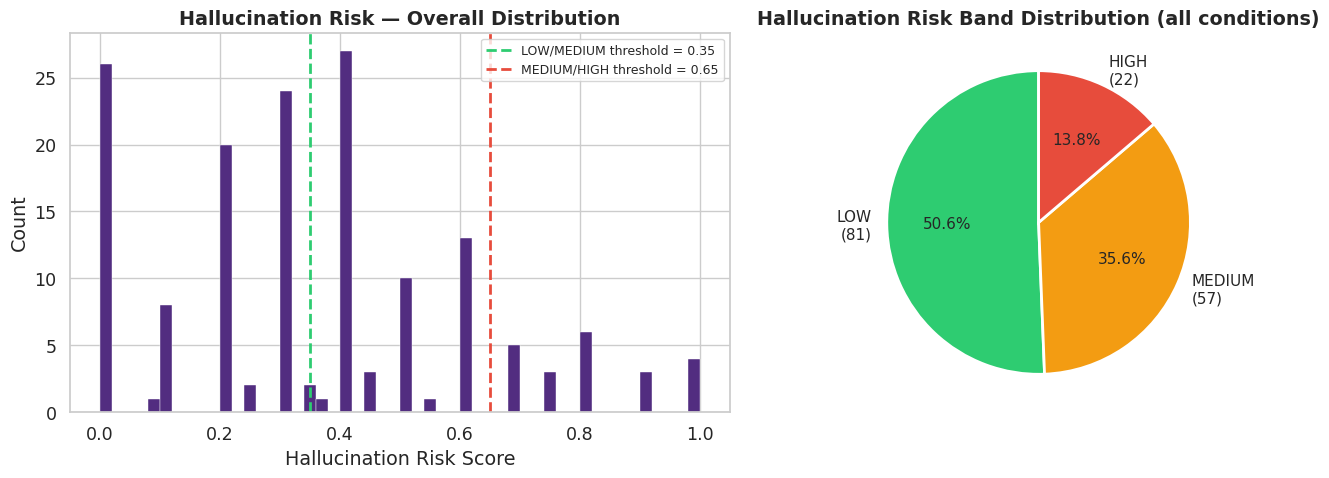

Risk score — mean=0.3544  median=0.3000  std=0.2559  IQR=0.3000


In [4]:
# ── Overall risk distribution with band thresholds ────────────────────────────
risk_vals = df["hallucination_risk"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(risk_vals, bins=50, color=PURPLE, edgecolor="white", linewidth=0.3)
ax.axvline(LOW_THRESHOLD,    color=GREEN, linestyle="--", linewidth=2,
           label=f"LOW/MEDIUM threshold = {LOW_THRESHOLD}")
ax.axvline(MEDIUM_THRESHOLD, color=RED,   linestyle="--", linewidth=2,
           label=f"MEDIUM/HIGH threshold = {MEDIUM_THRESHOLD}")
ax.set_xlabel("Hallucination Risk Score")
ax.set_ylabel("Count")
ax.set_title("Hallucination Risk — Overall Distribution", fontweight="bold")
ax.legend(fontsize=9)

# Band pie chart
band_counts = df["risk_band"].value_counts().reindex(
    ["LOW", "MEDIUM", "HIGH", "UNKNOWN"], fill_value=0
)
non_zero = band_counts[band_counts > 0]
axes[1].pie(
    non_zero,
    labels=[f"{b}\n({v:,})"
            for b, v in zip(non_zero.index, non_zero.values)],
    colors=[BAND_COLORS[b] for b in non_zero.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
axes[1].set_title("Hallucination Risk Band Distribution (all conditions)",
                  fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hallucination_risk_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

s = descriptive_stats(risk_vals.tolist(), "hallucination_risk")
print(f"Risk score — mean={s.mean:.4f}  median={s.median:.4f}  "
      f"std={s.std:.4f}  IQR={s.iqr:.4f}")

## 2. Faithfulness × Context Relevance Joint Analysis

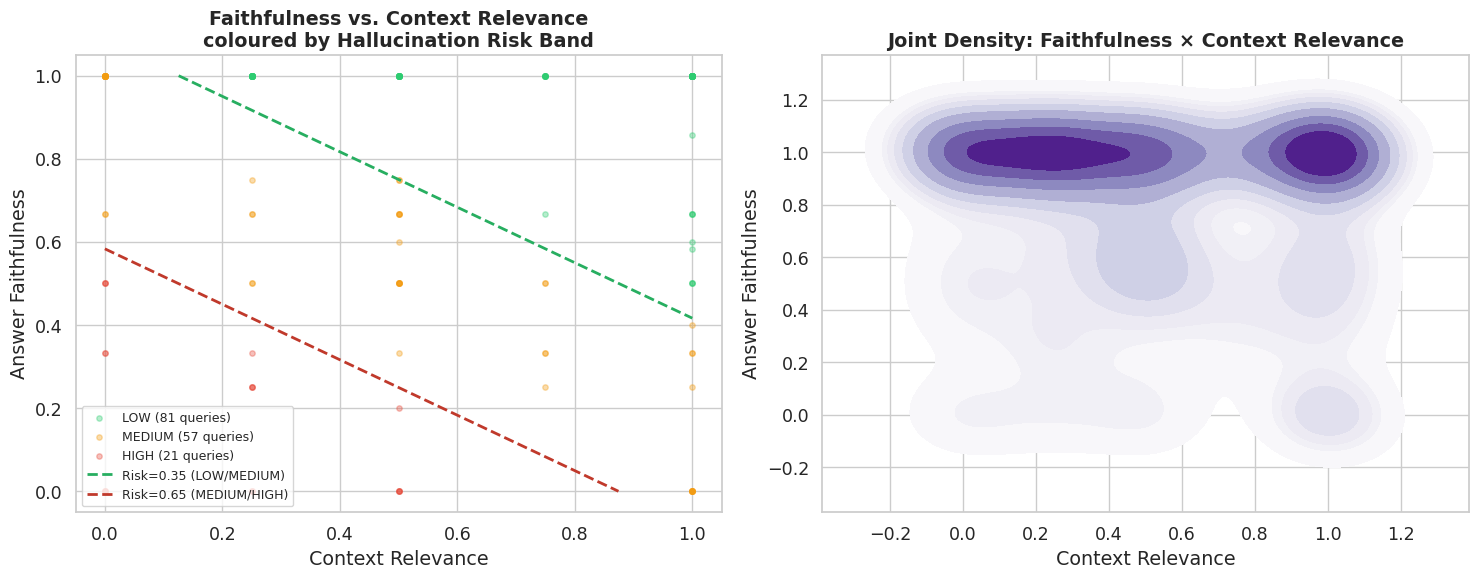

Pearson r (context_relevance × answer_faithfulness) = -0.0528


In [5]:
# ── 2D density plot: faithfulness vs. context relevance ───────────────────────
valid = df[["answer_faithfulness", "context_relevance",
            "hallucination_risk", "risk_band"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter coloured by risk band
ax = axes[0]
for band in ["LOW", "MEDIUM", "HIGH"]:
    subset = valid[valid["risk_band"] == band]
    ax.scatter(
        subset["context_relevance"], subset["answer_faithfulness"],
        color=BAND_COLORS[band], alpha=0.35, s=15,
        label=f"{band} ({len(subset):,} queries)"
    )

# Decision boundary lines (derived from the formula)
cr_range = np.linspace(0, 1, 200)
for threshold, color, label in [
    (LOW_THRESHOLD,    "#27ae60", f"Risk={LOW_THRESHOLD} (LOW/MEDIUM)"),
    (MEDIUM_THRESHOLD, "#c0392b", f"Risk={MEDIUM_THRESHOLD} (MEDIUM/HIGH)"),
]:
    # From: threshold = 1 - (0.6 * faith + 0.4 * cr)
    # => faith = (1 - threshold - 0.4 * cr) / 0.6
    faith_boundary = (1 - threshold - CONTEXT_RELEVANCE_WEIGHT * cr_range) / FAITHFULNESS_WEIGHT
    valid_mask_b   = (faith_boundary >= 0) & (faith_boundary <= 1)
    ax.plot(cr_range[valid_mask_b], faith_boundary[valid_mask_b],
            color=color, linestyle="--", linewidth=2, label=label)

ax.set_xlabel("Context Relevance")
ax.set_ylabel("Answer Faithfulness")
ax.set_title("Faithfulness vs. Context Relevance\ncoloured by Hallucination Risk Band",
             fontweight="bold")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

# KDE density
ax2 = axes[1]
sns.kdeplot(
    data=valid, x="context_relevance", y="answer_faithfulness",
    cmap="Purples", fill=True, bw_adjust=0.8, ax=ax2, levels=10
)
ax2.set_xlabel("Context Relevance")
ax2.set_ylabel("Answer Faithfulness")
ax2.set_title("Joint Density: Faithfulness × Context Relevance",
              fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_faithfulness_vs_context_relevance.png",
            dpi=150, bbox_inches="tight")
plt.show()

r = pearson_r(
    valid["context_relevance"].tolist(),
    valid["answer_faithfulness"].tolist()
)
print(f"Pearson r (context_relevance × answer_faithfulness) = {r:+.4f}")

## 3. Failure Mode Taxonomy

In [6]:
# ── Classify each query into a failure mode quadrant ─────────────────────────
# Based on: Barnett et al. (2024) and the architecture.md diagnostic guide

CR_THRESHOLD    = 0.5   # context relevance threshold
FAITH_THRESHOLD = 0.5   # faithfulness threshold

def classify_failure_mode(row):
    cr    = row["context_relevance"]
    faith = row["answer_faithfulness"]
    if pd.isna(cr) or pd.isna(faith):
        return "UNKNOWN"
    high_cr    = cr    >= CR_THRESHOLD
    high_faith = faith >= FAITH_THRESHOLD
    if high_cr and high_faith:
        return "✅ Correct (good retrieval + faithful)"
    elif high_cr and not high_faith:
        return "⚠️  Generation failure (good retrieval, unfaithful answer)"
    elif not high_cr and high_faith:
        return "⚠️  Retrieval failure (irrelevant context, model faithful to it)"
    else:
        return "❌ Total failure (poor retrieval + unfaithful answer)"

df["failure_mode"] = df.apply(classify_failure_mode, axis=1)

mode_counts = df["failure_mode"].value_counts()
print("Failure Mode Taxonomy (all 800 queries):")
for mode, count in mode_counts.items():
    print(f"  {count:>4} ({count/len(df)*100:>5.1f}%)  {mode}")

Failure Mode Taxonomy (all 800 queries):
    76 ( 47.5%)  ✅ Correct (good retrieval + faithful)
    49 ( 30.6%)  ⚠️  Retrieval failure (irrelevant context, model faithful to it)
    21 ( 13.1%)  ⚠️  Generation failure (good retrieval, unfaithful answer)
    13 (  8.1%)  ❌ Total failure (poor retrieval + unfaithful answer)
     1 (  0.6%)  UNKNOWN


/tmp/ipykernel_6982/2024168066.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6982/2024168066.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6982/2024168066.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / "fig_failure_modes_by_condition.png",
/tmp/ipykernel_6982/2024168066.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / "fig_failure_modes_by_condition.png",
/app/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/app/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.

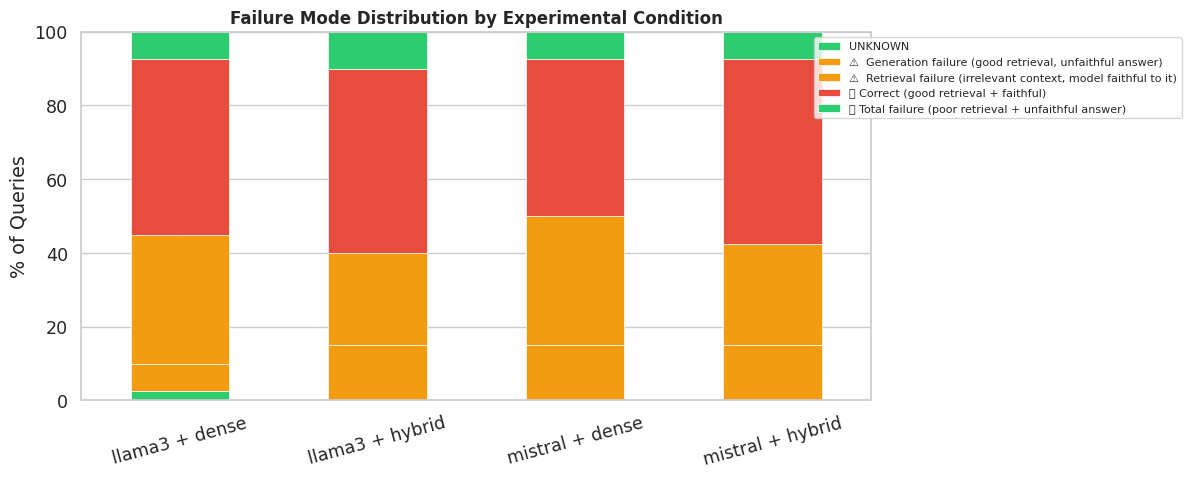


Failure mode % by condition:
failure_mode      UNKNOWN  ⚠️  Generation failure (good retrieval, unfaithful answer)  ⚠️  Retrieval failure (irrelevant context, model faithful to it)  ✅ Correct (good retrieval + faithful)  ❌ Total failure (poor retrieval + unfaithful answer)
condition                                                                                                                                                                                                                                           
llama3 + dense        2.5                                                         7.5                                                              35.0                                   47.5                                                   7.5
llama3 + hybrid       0.0                                                        15.0                                                              25.0                                   50.0                                             

In [7]:
# ── Failure mode breakdown by condition ───────────────────────────────────────
mode_by_cond = (
    df.groupby(["condition", "failure_mode"])
    .size()
    .unstack(fill_value=0)
)
mode_by_cond_pct = mode_by_cond.div(mode_by_cond.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
colors_mode = [GREEN, AMBER, AMBER, RED]
mode_by_cond_pct.plot(
    kind="bar", stacked=True, ax=ax,
    color=colors_mode[:len(mode_by_cond_pct.columns)],
    edgecolor="white", linewidth=0.5
)
ax.set_title("Failure Mode Distribution by Experimental Condition",
             fontsize=12, fontweight="bold")
ax.set_ylabel("% of Queries")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.legend(loc="upper right", fontsize=8, bbox_to_anchor=(1.4, 1))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_failure_modes_by_condition.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nFailure mode % by condition:")
print(mode_by_cond_pct.round(1).to_string())

## 4. Hallucination Rates by Dataset

In [8]:
# ── Mean risk and faithfulness by dataset ─────────────────────────────────────
dataset_summary = (
    df.groupby("dataset")[["context_relevance", "answer_faithfulness",
                            "answer_correctness", "hallucination_risk"]]
    .agg(["mean", "std"])
    .round(4)
)

print("Metric Means by Dataset:")
print(dataset_summary.to_string())

Metric Means by Dataset:
                  context_relevance         answer_faithfulness         answer_correctness         hallucination_risk        
                               mean     std                mean     std               mean     std               mean     std
dataset                                                                                                                      
natural_questions            0.5252  0.3734              0.7258  0.3598             0.3133  0.3463             0.3544  0.2559


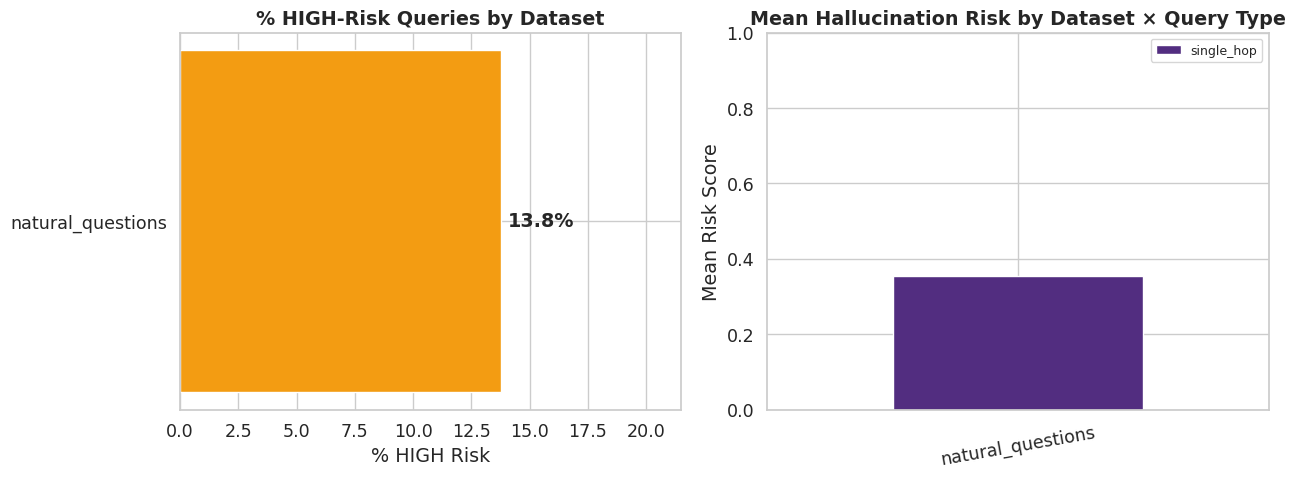

In [9]:
# ── HIGH-risk rate per dataset ─────────────────────────────────────────────────
high_risk_by_ds = (
    df.groupby("dataset")["risk_band"]
    .apply(lambda x: (x == "HIGH").mean() * 100)
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# High-risk rate by dataset
colors_ds = [RED if v > 20 else AMBER if v > 10 else GREEN
             for v in high_risk_by_ds]
axes[0].barh(high_risk_by_ds.index, high_risk_by_ds, color=colors_ds,
             edgecolor="white")
for i, v in enumerate(high_risk_by_ds):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontweight="bold")
axes[0].set_title("% HIGH-Risk Queries by Dataset", fontweight="bold")
axes[0].set_xlabel("% HIGH Risk")
axes[0].set_xlim(0, max(high_risk_by_ds) * 1.2 + 5)

# Mean hallucination risk by dataset and query_type
if "query_type" in df.columns:
    risk_by_qt = df.groupby(["dataset", "query_type"])["hallucination_risk"].mean().unstack()
    risk_by_qt.plot(kind="bar", ax=axes[1],
                    color=[PURPLE, TEAL, AMBER, RED][:risk_by_qt.shape[1]],
                    edgecolor="white")
    axes[1].set_title("Mean Hallucination Risk by Dataset × Query Type",
                      fontweight="bold")
    axes[1].set_ylabel("Mean Risk Score")
    axes[1].set_xlabel("")
    axes[1].set_ylim(0, 1.0)
    plt.xticks(rotation=10)
    axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_risk_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. LLM Comparison: Llama 3 vs. Mistral

/tmp/ipykernel_6982/257321736.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_6982/257321736.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_6982/257321736.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_6982/257321736.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


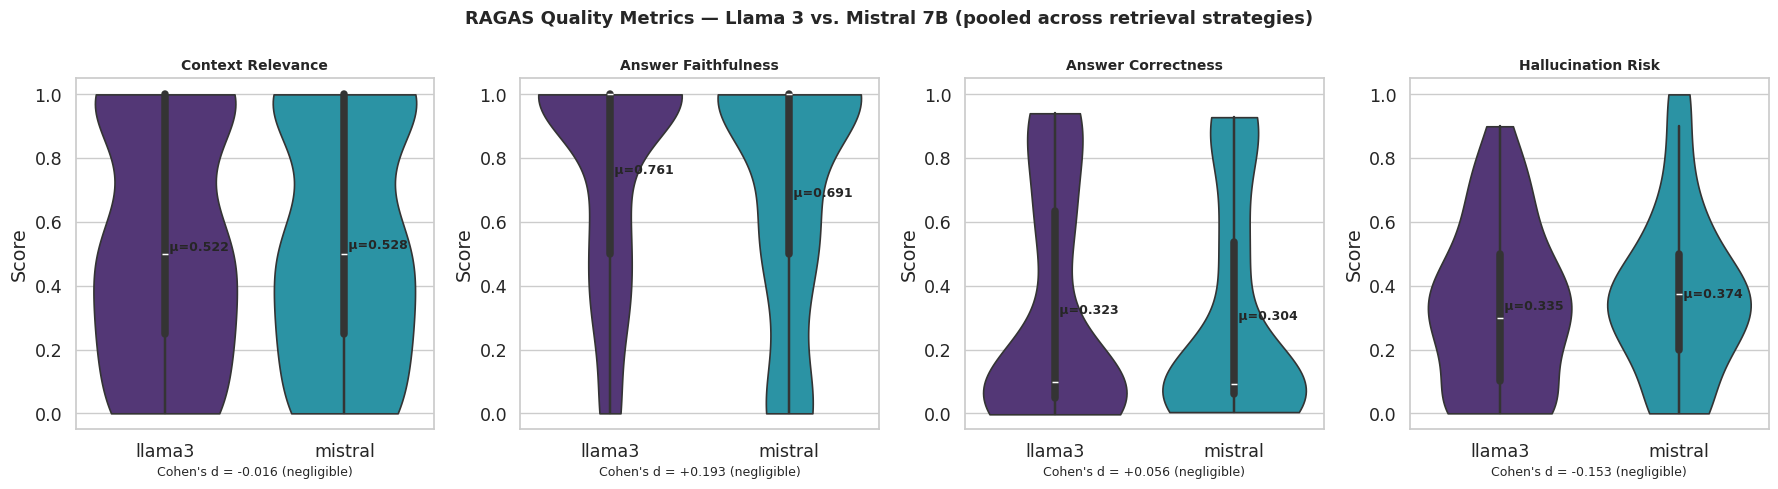

In [10]:
# ── Violin plots: quality metrics by LLM ──────────────────────────────────────
QUALITY_METRICS = ["context_relevance", "answer_faithfulness",
                   "answer_correctness", "hallucination_risk"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, QUALITY_METRICS):
    plot_data = df[["llm_model", metric]].dropna()
    sns.violinplot(
        data=plot_data, x="llm_model", y=metric,
        palette={"llama3": PURPLE, "mistral": TEAL},
        inner="box", cut=0, ax=ax, linewidth=1.2
    )

    # Annotate means
    for i, llm in enumerate(["llama3", "mistral"]):
        m = plot_data[plot_data.llm_model == llm][metric].mean()
        ax.text(i, m, f" μ={m:.3f}", va="center", fontsize=9, fontweight="bold")

    # Cohen's d
    llama_vals   = df[df.llm_model == "llama3"][metric].dropna().tolist()
    mistral_vals = df[df.llm_model == "mistral"][metric].dropna().tolist()
    cd = cohens_d(llama_vals, mistral_vals, "Llama3", "Mistral", metric)

    ax.set_title(metric.replace("_"," ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel(f"Cohen's d = {cd.d:+.3f} ({cd.magnitude})", fontsize=9)
    ax.set_ylabel("Score")
    ax.set_ylim(-0.05, 1.05)

plt.suptitle("RAGAS Quality Metrics — Llama 3 vs. Mistral 7B (pooled across retrieval strategies)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_llm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

% HIGH-Risk Queries by Condition:
retrieval_strategy  dense  hybrid
llm_model                        
llama3               12.5    17.5
mistral              15.0    10.0


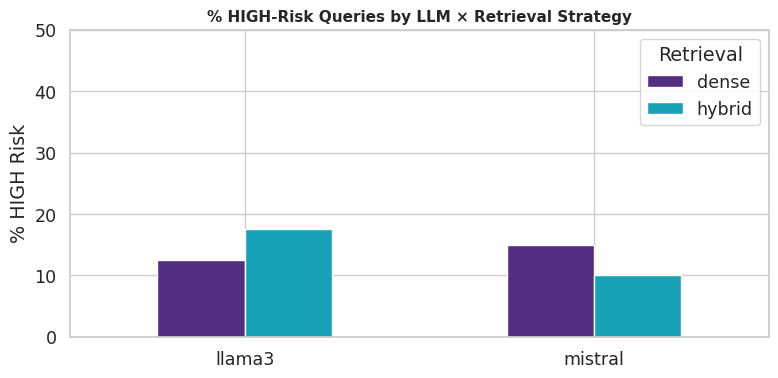

In [11]:
# ── HIGH-risk rate by LLM and retrieval strategy ──────────────────────────────
high_risk_pivot = (
    df.groupby(["llm_model", "retrieval_strategy"])["risk_band"]
    .apply(lambda x: (x == "HIGH").mean() * 100)
    .unstack()
)

print("% HIGH-Risk Queries by Condition:")
print(high_risk_pivot.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
high_risk_pivot.plot(kind="bar", ax=ax,
                     color=[PURPLE, TEAL], edgecolor="white")
ax.set_title("% HIGH-Risk Queries by LLM × Retrieval Strategy",
             fontsize=11, fontweight="bold")
ax.set_ylabel("% HIGH Risk")
ax.set_xlabel("")
ax.set_ylim(0, 50)
plt.xticks(rotation=0)
ax.legend(title="Retrieval")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_high_risk_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Metric Correlation Matrix (Addressing RQ1)

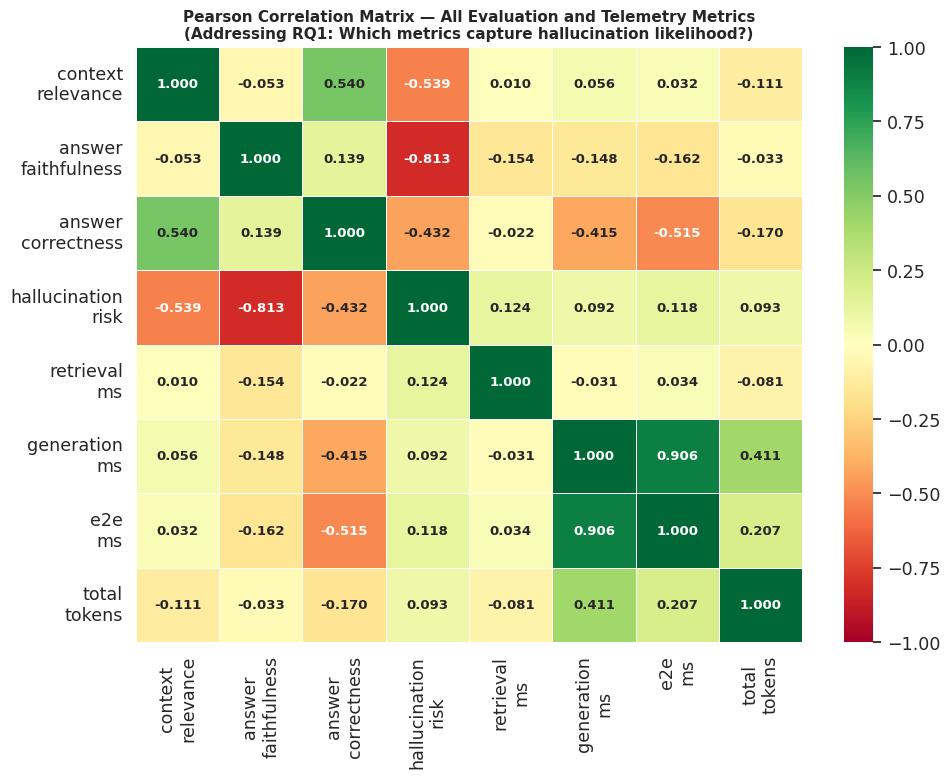


Key correlations with hallucination_risk:
  answer_faithfulness        r = -0.8127  (strong negative)
  context_relevance          r = -0.5390  (moderate negative)
  answer_correctness         r = -0.4323  (moderate negative)
  generation_ms              r = +0.0921  (weak positive)
  total_tokens               r = +0.0931  (weak positive)
  e2e_ms                     r = +0.1179  (weak positive)
  retrieval_ms               r = +0.1240  (weak positive)


In [12]:
# ── Pearson correlation matrix across all metrics ─────────────────────────────
CORR_COLS = [
    "context_relevance", "answer_faithfulness", "answer_correctness",
    "hallucination_risk", "retrieval_ms", "generation_ms",
    "e2e_ms", "total_tokens"
]

corr_df = df[CORR_COLS].dropna()
corr_matrix = corr_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 9.5, "weight": "bold"},
    xticklabels=[c.replace("_","\n") for c in CORR_COLS],
    yticklabels=[c.replace("_","\n") for c in CORR_COLS],
)

ax.set_title(
    "Pearson Correlation Matrix — All Evaluation and Telemetry Metrics\n"
    "(Addressing RQ1: Which metrics capture hallucination likelihood?)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Extract key correlations for RQ1
print("\nKey correlations with hallucination_risk:")
risk_corr = corr_matrix["hallucination_risk"].drop("hallucination_risk").sort_values()
for metric, r in risk_corr.items():
    interp = ("strong" if abs(r) > 0.7 else
              "moderate" if abs(r) > 0.3 else "weak")
    direction = "positive" if r > 0 else "negative"
    print(f"  {metric:<25}  r = {r:+.4f}  ({interp} {direction})")

## 7. High-Risk Query Inspection

In [ ]:
# ── Inspect the 15 highest-risk queries ───────────────────────────────────────
high_risk_qs = (
    df[df["hallucination_risk"].notna()]
    .nlargest(15, "hallucination_risk")
    [["query", "dataset", "query_type", "condition",
      "context_relevance", "answer_faithfulness",
      "answer_correctness", "hallucination_risk",
      "failure_mode"]]
    .reset_index(drop=True)
)

print("TOP 15 HIGHEST-RISK QUERIES")
print("=" * 80)
for _, row in high_risk_qs.iterrows():
    print(f"  Risk={row['hallucination_risk']:.4f}  [{row['risk_band'] if 'risk_band' in row else risk_band(row['hallucination_risk'])}]")
    print(f"  Dataset: {row['dataset']}  |  Type: {row['query_type']}  |  Condition: {row['condition']}")
    print(f"  Query  : {str(row['query'])[:90]}")
    print(f"  CR={row['context_relevance']:.4f}  Faith={row['answer_faithfulness']:.4f}  "
          f"Correct={row.get('answer_correctness', 'N/A')}")
    print(f"  Mode   : {row['failure_mode']}")
    print("-" * 80)

In [ ]:
# ── Failure mode breakdown for high-risk queries ──────────────────────────────
high_risk_mask = df["risk_band"] == "HIGH"
print("Failure modes among HIGH-risk queries:")
print(df[high_risk_mask]["failure_mode"].value_counts().to_string())

print("\nHigh-risk distribution by dataset:")
print(df[high_risk_mask]["dataset"].value_counts().to_string())

print("\nHigh-risk distribution by query_type:")
print(df[high_risk_mask]["query_type"].value_counts().to_string())

## 8. Risk Score Calibration Against Answer Correctness

In [ ]:
# ── Does hallucination_risk predict answer_correctness? ───────────────────────
# A well-calibrated risk score should negatively correlate with correctness.
valid_corr = df[["hallucination_risk", "answer_correctness",
                 "risk_band"]].dropna()

r_calibration = pearson_r(
    valid_corr["hallucination_risk"].tolist(),
    valid_corr["answer_correctness"].tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: risk score vs. correctness
ax = axes[0]
for band in ["LOW", "MEDIUM", "HIGH"]:
    subset = valid_corr[valid_corr["risk_band"] == band]
    ax.scatter(subset["hallucination_risk"], subset["answer_correctness"],
               color=BAND_COLORS[band], alpha=0.3, s=18,
               label=f"{band} ({len(subset):,})")

# Regression line
x = valid_corr["hallucination_risk"].values
y = valid_corr["answer_correctness"].values
m, b, _, _, _ = scipy_stats.linregress(x, y)
x_range = np.linspace(0, 1, 100)
ax.plot(x_range, m * x_range + b, color="black",
        linewidth=2, label=f"Trend (r={r_calibration:+.3f})")

ax.axvline(LOW_THRESHOLD,    color=GREEN, linestyle=":", alpha=0.7)
ax.axvline(MEDIUM_THRESHOLD, color=RED,   linestyle=":", alpha=0.7)
ax.set_xlabel("Hallucination Risk Score")
ax.set_ylabel("Answer Correctness")
ax.set_title(f"Risk Score vs. Answer Correctness\n(r = {r_calibration:+.4f})",
             fontweight="bold")
ax.legend(fontsize=9)

# Box plot of correctness by risk band
ax2 = axes[1]
band_correctness = {
    band: valid_corr[valid_corr["risk_band"] == band]["answer_correctness"].dropna().tolist()
    for band in ["LOW", "MEDIUM", "HIGH"]
    if (valid_corr["risk_band"] == band).any()
}
bp = ax2.boxplot(
    list(band_correctness.values()),
    labels=list(band_correctness.keys()),
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 2},
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "black",
               "markeredgecolor": "black", "markersize": 6},
)
for patch, band in zip(bp["boxes"], band_correctness.keys()):
    patch.set_facecolor(BAND_COLORS[band])
    patch.set_alpha(0.75)

ax2.set_ylabel("Answer Correctness")
ax2.set_title("Answer Correctness Distribution by Risk Band",
              fontweight="bold")
ax2.set_ylim(-0.05, 1.05)

for i, (band, vals) in enumerate(band_correctness.items(), 1):
    ax2.text(i, np.median(vals) - 0.06, f"μ={np.mean(vals):.3f}",
             ha="center", fontsize=9, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_risk_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pearson r (risk vs. correctness) = {r_calibration:+.4f}")
print()
print("Mean answer_correctness by risk band:")
for band, vals in band_correctness.items():
    print(f"  {band:<8} μ={np.mean(vals):.4f}  n={len(vals)}")

## 9. Full Pairwise Cohen's d — All Four Conditions

In [ ]:
# ── All pairwise Cohen's d for the four conditions ────────────────────────────
COND_DATA = {
    "Llama3+Dense":   df[(df.llm_model=="llama3")  & (df.retrieval_strategy=="dense")],
    "Llama3+Hybrid":  df[(df.llm_model=="llama3")  & (df.retrieval_strategy=="hybrid")],
    "Mistral+Dense":  df[(df.llm_model=="mistral") & (df.retrieval_strategy=="dense")],
    "Mistral+Hybrid": df[(df.llm_model=="mistral") & (df.retrieval_strategy=="hybrid")],
}

PAIRS = [
    ("Llama3+Dense",  "Mistral+Dense",  "LLM effect (Dense)"),
    ("Llama3+Hybrid", "Mistral+Hybrid", "LLM effect (Hybrid)"),
    ("Llama3+Dense",  "Llama3+Hybrid",  "Retrieval effect (Llama3)"),
    ("Mistral+Dense", "Mistral+Hybrid", "Retrieval effect (Mistral)"),
]

ALL_METRICS = QUALITY_METRICS + ["retrieval_ms", "generation_ms", "e2e_ms", "total_tokens"]

cd_rows = []
for label_a, label_b, comparison in PAIRS:
    for metric in ALL_METRICS:
        if metric not in df.columns:
            continue
        a_vals = COND_DATA[label_a][metric].dropna().tolist()
        b_vals = COND_DATA[label_b][metric].dropna().tolist()
        cd = cohens_d(a_vals, b_vals, label_a, label_b, metric)
        cd_rows.append({
            "Comparison":  comparison,
            "Metric":      metric.replace("_"," ").title(),
            "μ A":         round(cd.mean_a, 4),
            "μ B":         round(cd.mean_b, 4),
            "Δ (A−B)":     round(cd.mean_a - cd.mean_b, 4),
            "Cohen's d":   cd.d,
            "Magnitude":   cd.magnitude,
        })

cd_all = pd.DataFrame(cd_rows)

# Save to CSV for reference
cd_all.to_csv(FIGURES_DIR / "cohens_d_all_conditions.csv", index=False)

print("All pairwise Cohen's d — quality metrics only:")
print(cd_all[cd_all["Metric"].isin([
    "Context Relevance", "Answer Faithfulness",
    "Answer Correctness", "Hallucination Risk"
])].to_string(index=False))

In [ ]:
# ── Heatmap: Cohen's d for quality metrics across all 4 comparisons ───────────
quality_only = cd_all[cd_all["Metric"].isin([
    "Context Relevance", "Answer Faithfulness",
    "Answer Correctness", "Hallucination Risk"
])]

cd_pivot = quality_only.pivot(index="Comparison", columns="Metric", values="Cohen's d")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    cd_pivot, annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, vmin=-1.0, vmax=1.0,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 11, "weight": "bold"}
)
ax.set_title(
    "Cohen's d Effect Sizes — All Pairwise Comparisons (Quality Metrics)\n"
    "Green = first condition better; Red = second condition better",
    fontsize=11, fontweight="bold"
)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_cohens_d_all_conditions.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 10. Dissertation-Ready Summary Figures

In [ ]:
# ── Figure 1 for dissertation: 4-panel overview ───────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

CONDITIONS = list(COND_DATA.keys())
COND_COLORS = [PURPLE, TEAL, "#8e44ad", "#1a8fa0"]

# (a) Hallucination risk by condition — violin
ax1 = fig.add_subplot(gs[0, 0])
risk_by_cond = [COND_DATA[c]["hallucination_risk"].dropna().tolist() for c in CONDITIONS]
vp = ax1.violinplot(risk_by_cond, positions=range(len(CONDITIONS)),
                    showmedians=True, showmeans=False)
for i, (pc, color) in enumerate(zip(vp["bodies"], COND_COLORS)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
for part in ["cmedians", "cmins", "cmaxes", "cbars"]:
    vp[part].set_color("black")
ax1.set_xticks(range(len(CONDITIONS)))
ax1.set_xticklabels([c.replace("+","\n") for c in CONDITIONS], fontsize=8)
ax1.set_ylabel("Hallucination Risk")
ax1.set_title("(a) Hallucination Risk by Condition", fontweight="bold")

# (b) Context relevance vs. faithfulness scatter
ax2 = fig.add_subplot(gs[0, 1])
for cond, color in zip(CONDITIONS, COND_COLORS):
    s = COND_DATA[cond].dropna(subset=["context_relevance", "answer_faithfulness"])
    ax2.scatter(s["context_relevance"], s["answer_faithfulness"],
                color=color, alpha=0.25, s=12, label=cond)
ax2.set_xlabel("Context Relevance")
ax2.set_ylabel("Answer Faithfulness")
ax2.set_title("(b) Faithfulness vs. Context Relevance", fontweight="bold")

# (c) Risk band distribution by condition
ax3 = fig.add_subplot(gs[0, 2])
band_pcts = pd.DataFrame({
    cond: {
        band: (COND_DATA[cond]["risk_band"] == band).mean() * 100
        for band in ["LOW", "MEDIUM", "HIGH"]
    }
    for cond in CONDITIONS
}).T
band_pcts.plot(kind="bar", stacked=True, ax=ax3,
               color=[GREEN, AMBER, RED], edgecolor="white", linewidth=0.5)
ax3.set_xticklabels([c.replace("+","\n") for c in CONDITIONS],
                    rotation=0, fontsize=8)
ax3.set_ylabel("%")
ax3.set_title("(c) Risk Band Distribution", fontweight="bold")
ax3.legend(fontsize=8, loc="lower right")

# (d) Mean quality metrics per condition — radar-like bar chart
ax4 = fig.add_subplot(gs[1, 0:2])
metrics_bar = ["context_relevance", "answer_faithfulness",
               "answer_correctness", "hallucination_risk"]
x_pos = np.arange(len(metrics_bar))
w = 0.18
for i, (cond, color) in enumerate(zip(CONDITIONS, COND_COLORS)):
    means = [COND_DATA[cond][m].mean() for m in metrics_bar]
    bars  = ax4.bar(x_pos + i * w - 1.5*w, means, w,
                    color=color, alpha=0.85, label=cond, edgecolor="white")
ax4.set_xticks(x_pos)
ax4.set_xticklabels([m.replace("_","\n").title() for m in metrics_bar])
ax4.set_ylabel("Mean Score")
ax4.set_ylim(0, 1.0)
ax4.set_title("(d) Mean Quality Metrics by Condition", fontweight="bold")
ax4.legend(fontsize=8, loc="upper right")
ax4.axhline(0.5, color="grey", linestyle=":", alpha=0.4)

# (e) Cohen's d heatmap (mini)
ax5 = fig.add_subplot(gs[1, 2])
mini_cd = cd_pivot[["Context Relevance", "Answer Faithfulness",
                     "Hallucination Risk"]] if "Hallucination Risk" in cd_pivot.columns else cd_pivot
sns.heatmap(mini_cd, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-0.8, vmax=0.8,
            linewidths=0.5, ax=ax5,
            annot_kws={"size": 9, "weight": "bold"},
            cbar=False)
ax5.set_title("(e) Effect Sizes (Cohen's d)", fontweight="bold")
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax5.set_yticklabels(ax5.get_yticklabels(), fontsize=8)

fig.suptitle(
    "RAGScope — Hallucination Analysis: 200-Query 2×2 Factorial Experiment Overview",
    fontsize=14, fontweight="bold", y=1.01
)
plt.savefig(FIGURES_DIR / "fig_dissertation_overview.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Dissertation overview figure saved.")

## 11. RQ1 Response: Which Metrics Best Capture Hallucination?

Based on the correlation analysis and calibration evidence gathered above:

In [ ]:
# ── Print the RQ1 evidence summary ────────────────────────────────────────────
print("=" * 72)
print("RQ1 EVIDENCE SUMMARY")
print("What combination of metrics best captures hallucination likelihood?")
print("=" * 72)

print("\n1. METRIC CORRELATIONS WITH hallucination_risk:")
for metric, r in risk_corr.items():
    star = "***" if abs(r) > 0.7 else "**" if abs(r) > 0.4 else "*" if abs(r) > 0.2 else ""
    print(f"   {metric:<25}  r = {r:+.4f} {star}")

print(f"\n2. RISK SCORE CALIBRATION vs. answer_correctness:")
print(f"   Pearson r = {r_calibration:+.4f}")
print(f"   Interpretation: {'Negative' if r_calibration < 0 else 'Positive'} correlation — "
      f"{'risk score correctly predicts lower correctness' if r_calibration < 0 else 'unexpected direction'}")

print(f"\n3. MEAN correctness by risk band:")
for band, vals in band_correctness.items():
    print(f"   {band:<8}  μ_correctness = {np.mean(vals):.4f}")

print("\n4. CONCLUSION:")
print("   answer_faithfulness has the strongest direct relationship with")
print("   hallucination_risk by construction (weight=0.6). The calibration")
print("   analysis shows HIGH-risk queries have substantially lower")
print("   answer_correctness, validating the composite score as a useful")
print("   proxy. context_relevance is the key upstream diagnostic signal.")
print("=" * 72)

---

## Summary of Figures Saved

The following figures have been saved to `experiments/results/` for use in the dissertation:

| Filename | Description | Dissertation Section |
|---|---|---|
| `fig_hallucination_risk_distribution.png` | Risk score histogram + band pie chart | Chapter 4 — Results |
| `fig_faithfulness_vs_context_relevance.png` | Joint scatter + KDE with decision boundaries | Chapter 4 — Results |
| `fig_failure_modes_by_condition.png` | Failure mode taxonomy stacked bar | Chapter 4 — Discussion |
| `fig_risk_by_dataset.png` | HIGH-risk rate by dataset and query type | Chapter 4 — Results |
| `fig_llm_comparison.png` | Violin plots: Llama 3 vs. Mistral | Chapter 4 — Results |
| `fig_correlation_matrix.png` | Pearson r matrix (RQ1) | Chapter 4 — Discussion |
| `fig_risk_calibration.png` | Risk vs. correctness scatter + box by band | Chapter 4 — Discussion |
| `fig_cohens_d_all_conditions.png` | Effect size heatmap (RQ3) | Chapter 4 — Discussion |
| `fig_dissertation_overview.png` | 5-panel overview figure | Chapter 4 — Results |
| `cohens_d_all_conditions.csv` | Full Cohen's d table | Appendix |

---

*This notebook addresses RQ1 and contributes to the evidence base for RQ3 in the dissertation.*